In [31]:
!pip install mlflow
!pip install python-dotenv
!pip install seaborn
!pip install emoji
!pip install langdetect


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 981.5/981.5 kB 15.3 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993364 sha256=332eb33d4a4479adec7422232ce361b74249dcc63f8b686d871ec26dcd5e7f28
  Stored in directory: c:\users\edoah\appdata\local\pip\cache\wheels\0a\f2\b2\e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import mlflow 
import mlflow.sklearn
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import os
import json
import spacy
import re
import emoji
from nltk.stem.snowball import SnowballStemmer
from langdetect import detect, LangDetectException
from dotenv import load_dotenv


In [ ]:
# Charger les variables d'environnement depuis .env (force reload)
load_dotenv(override=True)

# Vérifier que les variables sont bien chargées
tracking_uri = os.getenv("MLFLOW_TRACKING_URI")
experiment_name = os.getenv("EXPERIMENT_NAME")  # Par défaut = tracking_uri
print(f"MLFLOW_TRACKING_URI: {tracking_uri}")
print(f"EXPERIMENT_NAME: {experiment_name}")

mlflow.set_tracking_uri(tracking_uri)

mlflow.set_experiment(experiment_name)

with mlflow.start_run():
    mlflow.log_metric("Connexion", 1)
    print("✓ Connexion au serveur MLflow réussie !")

MLFLOW_TRACKING_URI: https://ulrichsama.pythonanywhere.com/
EXPERIMENT_NAME: SentimentClassification
✓ Connexion au serveur MLflow réussie !
🏃 View run upbeat-fish-360 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/fab9bb5d33a54c61873ba17dc492a366
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [17]:
import wget

#DATASET_URL = "https://github.com/archiducarmel/ESIEA_MLOPS/releases/download/datas/training.1600000.processed.noemoticon.csv"
DATASET_URL = "./data/training.1600000.processed.noemoticon.csv"
dataset = pd.read_csv(DATASET_URL,names=['target', 'ids', 'date', 'flag', 'user', 'text'], encoding='latin-1')

In [18]:
with mlflow.start_run(run_name="data_exploration"):
    dataset = dataset.loc[:, ["target", "text"]]
    dataset["target"] = dataset["target"].replace(4, 1)
    print(dataset.info())
    mlflow.log_params(dataset)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   text    1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB
None
🏃 View run data_exploration at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/e64d14b3a9094688a68aea5ce07fa005
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


count    1600000.0
mean           0.5
std            0.5
min            0.0
25%            0.0
50%            0.5
75%            1.0
max            1.0
Name: target, dtype: float64


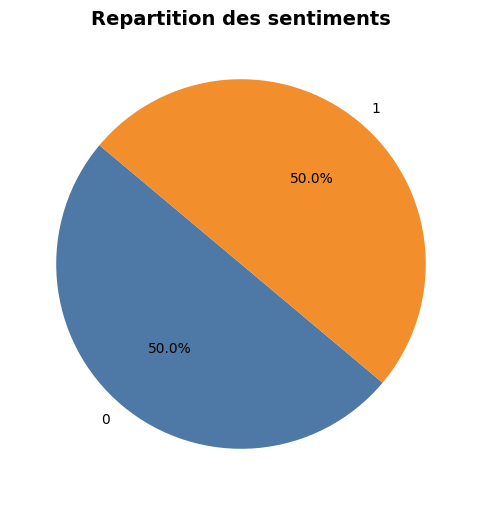

artifact_uri: file:///home/ulrichsama/mlflow_project/mlruns/231745430229609696/6d4e95e07c314975b402c545b442fb2f/artifacts
artifacts: [<FileInfo: file_size=None, is_dir=True, path='artifacts/plots'>]
[<FileInfo: file_size=None, is_dir=True, path='artifacts/plots'>]
🏃 View run data_visualisation at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/6d4e95e07c314975b402c545b442fb2f
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [19]:
print(dataset["target"].describe())
repartition = dataset["target"].value_counts()
repartition_pct = dataset["target"].value_counts(normalize=True) * 100


with mlflow.start_run(run_name="data_visualisation"):

    # ==================================================
    # GRAPHIQUE 1 : Le Pie Chart
    # ==================================================
    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.pie(
        repartition,
        labels=repartition.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=["#4e79a7", "#f28e2b"]
    )
    ax1.set_title("Repartition des sentiments", fontsize=14, weight="bold")
    mlflow.log_figure(fig1, "plots/pie_chart_repartition.jpg")
    plt.show()
    plt.close(fig1)


    # ==================================================
    # GRAPHIQUE 2 : Le Bar Chart (Histogramme)
    # ==================================================
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    bars = ax2.bar(
        repartition_pct.index,
        repartition_pct.values, 
        color=["#4e79a7", "#f28e2b"]
    )
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(
            f"{height:.1f}%",  # Texte à afficher
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height,
            ),  # Position (x, y)
            xytext=(0, 3),  # Décalage de 3 points vers le haut
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
        )
    ax2.set_title("Répartition en pourcentage des émotions", fontsize=14, weight="bold")
    ax2.set_xlabel("Emotions")
    ax2.set_ylabel("Repartition")

    # Log du deuxième graphique (dans le même dossier 'plots')
    fig2.savefig("bar_chart_pourcentage.png")
    mlflow.log_figure(fig2, "plots/bar_chart_pourcentage.jpg")
    print("artifact_uri:", mlflow.get_artifact_uri())
    print("artifacts:", mlflow.artifacts.list_artifacts(mlflow.get_artifact_uri()))
    print(mlflow.artifacts.list_artifacts(mlflow.get_artifact_uri()))
    plt.close(fig2)


In [20]:
# ALTERNATIVE : Logger les statistiques des plots en tant que métriques
# (marche avec tous les serveurs MLflow, pas besoin de backend d'artifacts)

with mlflow.start_run(run_name="data_statistics"):
    # Logger les statistiques du dataset
    mlflow.log_param("sentiments_0", int(repartition[0]))
    mlflow.log_param("sentiments_1", int(repartition[1]))
    mlflow.log_param("sentiments_0_pct", f"{repartition_pct[0]:.2f}%")
    mlflow.log_param("sentiments_1_pct", f"{repartition_pct[1]:.2f}%")
    mlflow.log_param("total_samples", len(dataset))
    
    print("✓ Statistics logged successfully!")
    print(f"  - Sentiment 0: {repartition[0]} samples ({repartition_pct[0]:.2f}%)")
    print(f"  - Sentiment 1: {repartition[1]} samples ({repartition_pct[1]:.2f}%)")

✓ Statistics logged successfully!
  - Sentiment 0: 800000 samples (50.00%)
  - Sentiment 1: 800000 samples (50.00%)
🏃 View run data_statistics at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/a8f8577b678e4942922c67e2ceb4a8c8
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [21]:
from sklearn.model_selection import train_test_split

SAMPLING_RATIO = 0.02
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(dataset["text"], dataset["target"], test_size=0.3, stratify=dataset["target"], random_state=RANDOM_STATE)

repartition = y_train.value_counts()
repartition_pct = y_train.value_counts(normalize=True) * 100
print(repartition)
with mlflow.start_run(run_name="data_sampling"):
    mlflow.log_param("RANDOM_STATE", RANDOM_STATE)
    mlflow.log_param("SAMPLING_RATIO", SAMPLING_RATIO)
    

    
    # À compléter :
    # 1. Définissez SAMPLING_RATIO = 0.02 et RANDOM_STATE = 42
    # 2. Utilisez train_test_split avec stratify=df['sentiment']
    # 3. Vérifiez la conservation de la distribution
    # 4. Loggez les paramètres dans MLflow
    # 5. Optionnel : créez une visualisation de comparaison
    
    

target
1    560000
0    560000
Name: count, dtype: int64
🏃 View run data_sampling at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/3f0f799ec42e4530a35a60985c61937e
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [28]:
# Dictionnaire des emojis - À compléter selon vos besoins
with open('dict_emojis.json', 'r', encoding='utf-8') as fichier:
    # Transforme le contenu du fichier JSON en dictionnaire Python
    dict_emojis = json.load(fichier)

try:
    with open('stopwords.txt', 'r', encoding='utf-8') as fichier:
        stopwords = set(ligne.strip() for ligne in fichier if ligne.strip())
        
    print(f"{len(stopwords)} stopwords chargés avec succès !")
except FileNotFoundError:
    print("Erreur : Le fichier 'stopwords.txt' est introuvable.")

423 stopwords chargés avec succès !


In [ ]:
try:
    nlp_models = {
        "fr": spacy.load("fr_core_news_sm"),
        "en": spacy.load("en_core_web_sm")
    }
    
except OSError:
    print("Erreur : Le modèle SpaCy n'est pas installé. Lancez : python -m spacy download fr_core_news_sm")

stemmers = {
    "fr": SnowballStemmer("french"),
    "en": SnowballStemmer("english")
}

def preprocess_text(tweet, stem_or_lem="lem"):
    """
    Prétraite un tweet selon le pipeline décrit
    
    Args:
        tweet : str, texte du tweet à prétraiter
        stem_or_lem : str, "lem" pour lemmatisation, "stem" pour stemming
    
    Returns:
        str : texte prétraité
    """

    try:
        langue_detectee = detect(tweet)
    except LangDetectException:
        langue_detectee = "fr" # Valeur par défaut si le texte est vide ou indétectable
        
    # Si la langue n'est ni anglais ni français, on force l'anglais par défaut
    if langue_detectee not in ["fr", "en"]:
        langue_detectee = "en"

    texte = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)
    texte = re.sub(r'@\w+', '', texte)
    texte = re.sub(r'#\w+', '', texte)
    texte = emoji.demojize(texte, language=langue_detectee)
    for emoticon, valeur_texte in dict_emojis.items():
        texte = texte.replace(emoticon, f" {valeur_texte} ")
    texte = re.sub(r'\s+', ' ', texte).strip()

    doc = nlp_models[langue_detectee](texte)
    mots =[]
    for token in doc:
        if token.is_punct or token.is_space:
            continue  
        mot_original = token.text.lower()
        if stem_or_lem == "lem":
            mot_transforme = token.lemma_.lower()
        elif stem_or_lem == "stem":
            mot_transforme = stemmer.stem(mot_original)
            
        if mot_original not in stopwords and mot_transforme not in stopwords:
            mots.append(mot_transforme)
    return mots
    
    # À compléter : implémentez le pipeline de prétraitement
    # 1. Nettoyage de base (URLs, mentions, hashtags, etc.)
    # 2. Remplacement des emojis
    # 3. Tokenisation et suppression des stop words
    # 4. Lemmatisation ou stemming
    

# Test et logging dans MLflow
with mlflow.start_run(run_name="text_preprocessing"):
    # À compléter : testez votre fonction et loggez les paramètres
    
    example_text = "This is a sample tweet with @user and http://example.com :) !!!"
    processed = preprocess_text(example_text)
    print(f"Original: {example_text}")
    print(f"Processed: {processed}")
    

Original: This is a sample tweet with @user and http://example.com :) !!!
Processed: ['sample', 'tweet', 'smile']
🏃 View run text_preprocessing at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/b864b8415e844802bc0607e9256f4ee0
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
